In [1]:
import pandas as pd
import re
import seaborn as sns 
import matplotlib.pyplot as plt

## 1. Chargement et premier aperçu

### 1.1 Charger le dataset

In [61]:
# lire le fichier txt (adapter sep si besoin)
df = pd.read_csv(r"C:\Users\21276\Desktop\master Fp\python avancee\mini-project\archive\KDDTest-21.txt")  # ou sep=" " pour espace

 #sauvegarder en csv
df.to_csv(r"C:\Users\21276\Desktop\master Fp\python avancee\mini-project\KDDTest+.csv", index=False)

In [42]:
df=pd.read_csv(r"C:\Users\21276\Desktop\master Fp\python avancee\mini-project\KDDTrain+.csv")

In [41]:
df_test  = pd.read_csv(r"C:\Users\21276\Desktop\master Fp\python avancee\mini-project\KDDTest+.csv")

In [ ]:
df=pd.read_csv(r"C:\Users\21276\Desktop\master Fp\python avancee\mini-project\KDDTrain+_with_columns.csv")

In [43]:
columns = (['duration'
,'protocol_type'
,'service'
,'flag'
,'src_bytes'
,'dst_bytes'
,'land'
,'wrong_fragment'
,'urgent'
,'hot'
,'num_failed_logins'
,'logged_in'
,'num_compromised'
,'root_shell'
,'su_attempted'
,'num_root'
,'num_file_creations'
,'num_shells'
,'num_access_files'
,'num_outbound_cmds'
,'is_host_login'
,'is_guest_login'
,'count'
,'srv_count'
,'serror_rate'
,'srv_serror_rate'
,'rerror_rate'
,'srv_rerror_rate'
,'same_srv_rate'
,'diff_srv_rate'
,'srv_diff_host_rate'
,'dst_host_count'
,'dst_host_srv_count'
,'dst_host_same_srv_rate'
,'dst_host_diff_srv_rate'
,'dst_host_same_src_port_rate'
,'dst_host_srv_diff_host_rate'
,'dst_host_serror_rate'
,'dst_host_srv_serror_rate'
,'dst_host_rerror_rate'
,'dst_host_srv_rerror_rate'
,'attack'
,'level'])

In [44]:
df.columns = columns
#df_test.columns= columns

In [45]:
#Vue globale du dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [38]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11849 entries, 0 to 11848
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     11849 non-null  int64  
 1   protocol_type                11849 non-null  int64  
 2   service                      11849 non-null  int64  
 3   flag                         11849 non-null  int64  
 4   src_bytes                    11849 non-null  int64  
 5   dst_bytes                    11849 non-null  int64  
 6   land                         11849 non-null  int64  
 7   wrong_fragment               11849 non-null  int64  
 8   urgent                       11849 non-null  int64  
 9   hot                          11849 non-null  int64  
 10  num_failed_logins            11849 non-null  int64  
 11  logged_in                    11849 non-null  int64  
 12  num_compromised              11849 non-null  int64  
 13  root_shell      

## 2. Statistiques descriptives + cat_features/numeric_columns

In [46]:
#Identifier les colonnes numériques vs catégorielles
numeric_columns= df.select_dtypes(include=['float64', 'int64']).columns
cat_features = df.select_dtypes(include='object').columns
df[numeric_columns].describe().T



,count,mean,std,min,25%,50%,75%,max
duration,125972.0,287.146929,2.604526e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125972.0,45567.100824,5.870354e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125972.0,19779.271433,4.021285e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125972.0,0.000198,1.408613e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125972.0,0.022688,2.535310e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125972.0,0.000111,1.436608e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125972.0,0.204411,2.149977e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125972.0,0.001222,4.523932e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125972.0,0.395739,4.890107e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125972.0,0.279253,2.394214e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [46]:
df.shape

(125972, 43)

In [47]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [47]:
print(cat_features)

Index(['protocol_type', 'service', 'flag', 'attack'], dtype='object')


In [71]:
#Comparer les statistiques entre connexions normales et attaques en filtrant par attack_type
print("statistiques pour les connexions normales ")
df[df["attack"]=='normal'][numeric_columns].describe().T


statistiques pour les connexions normales 


,count,mean,std,min,25%,50%,75%,max
duration,67342.0,168.589899,1304.461651,0.0,0.00,0.00,0.00,40504.0
src_bytes,67342.0,13133.467064,418116.235843,0.0,129.00,233.00,324.00,89581520.0
dst_bytes,67342.0,4329.749517,65463.301630,0.0,105.00,379.00,2056.00,7028652.0
land,67342.0,0.000104,0.010195,0.0,0.00,0.00,0.00,1.0
wrong_fragment,67342.0,0.000000,0.000000,0.0,0.00,0.00,0.00,0.0
urgent,67342.0,0.000148,0.017233,0.0,0.00,0.00,0.00,3.0
hot,67342.0,0.230658,2.308353,0.0,0.00,0.00,0.00,77.0
num_failed_logins,67342.0,0.001381,0.049480,0.0,0.00,0.00,0.00,4.0
logged_in,67342.0,0.710656,0.453461,0.0,0.00,1.00,1.00,1.0
num_compromised,67342.0,0.507083,32.743564,0.0,0.00,0.00,0.00,7479.0


In [123]:
print("statistiques pour les connexions attaques ")
df[df["attack"]!='normal'][numeric_columns].describe().T


statistiques pour les connexions attaques 


,count,mean,std,min,25%,50%,75%,max
duration,58630.0,423.320689,3.547685e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,58630.0,82820.141327,8.593025e+06,0.0,0.00,0.00,0.00,1.379964e+09
dst_bytes,58630.0,37524.482159,5.893991e+06,0.0,0.00,0.00,0.00,1.309937e+09
land,58630.0,0.000307,1.751916e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,58630.0,0.048746,3.699164e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,58630.0,0.000068,1.011602e-02,0.0,0.00,0.00,0.00,2.000000e+00
hot,58630.0,0.174262,1.951861e+00,0.0,0.00,0.00,0.00,2.800000e+01
num_failed_logins,58630.0,0.001040,3.981411e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,58630.0,0.034027,1.813000e-01,0.0,0.00,0.00,0.00,1.000000e+00
num_compromised,58630.0,0.017568,2.368118e-01,0.0,0.00,0.00,0.00,3.800000e+01


##### la moyenne pour la collonne duration dans le cas d'attaque est plus eleve(423s) que dans le cas normal(168), cela lie au fait que quelques type d'attaque comme R2L ou U2R prennent des sessions longues en revanche les deux autres attaques (Dos, probe) ont une duration proche de zero. dans ce contexe on doit calculer la moyenne de duration pour chaque type d'attque pour visualiser ce comportement.

In [74]:
# Voir la duration moyenne par type d'attaque
df.groupby('attack')['duration'].mean().sort_values(ascending=False)

attack
portsweep          8246.697032
warezclient         705.092135
spy                 318.000000
multihop            184.000000
normal              168.589899
rootkit             100.800000
buffer_overflow      91.700000
perl                 41.333333
loadmodule           36.222222
ftp_write            32.375000
warezmaster          15.050000
imap                  6.545455
phf                   4.500000
ipsweep               3.616004
guess_passwd          2.716981
back                  0.297071
satan                 0.127718
neptune               0.000049
nmap                  0.000000
pod                   0.000000
land                  0.000000
smurf                 0.000000
teardrop              0.000000
Name: duration, dtype: float64

#### portsweep a une duration moyenne de 8246s (~2h17) — c'est de loin la plus haute, ce qui est inattendu pour une attaque de type Probe. Cela s'explique par le fait que certains scans de ports lents (slow scan) délibérément étalent leurs connexions dans le temps pour éviter la détection par les IDS.
#### les attaques Dos(duration=0):
     neptune  ->0.000049  ≈ 0
     pod      ->0.000000
     land     ->0.000000
     smurf    ->0.000000
     teardrop ->0.000000
#### Observation 3 — Les attaques R2L ont des durées intermédiaires
    warezclient  → 705s
    multihop     → 184s
    ftp_write    →  32s
    guess_passwd →   2.7s
#### Observation 5 — U2R ont des durées modérées
    rootkit          → 100s
    buffer_overflow  →  91s
    perl             →  41s
    loadmodule       →  36s

In [117]:
df.groupby('num_failed_logins').size()

num_failed_logins
0    125850
1       104
2         9
3         5
4         3
5         1
dtype: int64

In [124]:
df[df['num_failed_logins']==5]

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
101345,23,tcp,telnet,SF,104,276,0,0,0,0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,guess_passwd,7


##### Une seule connexion présente 5 tentatives de login échouées, et elle est effectivement classifiée comme guess_passwd. Cependant la majorité des attaques guess_passwd du dataset ont num_failed_logins faible ou nul, ce qui indique que les attaquants réels fragmentent leurs tentatives sur plusieurs connexions pour éviter la détection. Cela démontre que num_failed_logins seul est insuffisant pour détecter ce type d'attaque — il doit être croisé avec d'autres features comme duration, failed_logins et src_bytes

In [91]:
print(df.shape)
print(df_test.shape)

(125972, 43)
(11849, 43)


In [11]:
df.tail(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
125962,0,tcp,http,SF,334,1600,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,normal,21
125963,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.0,0.00,0.0,neptune,21
125964,0,tcp,smtp,SF,2233,365,0,0,0,0,...,1.00,0.00,1.00,1.00,0.00,0.0,0.00,0.0,normal,19
125965,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.07,0.00,0.00,1.00,1.0,0.00,0.0,neptune,21
125966,0,tcp,http,SF,359,375,0,0,0,0,...,1.00,0.00,0.33,0.04,0.33,0.0,0.00,0.0,normal,18
125967,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.0,0.00,0.0,neptune,20
125968,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.0,0.00,0.0,normal,21
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.0,0.01,0.0,normal,18
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.0,0.00,0.0,neptune,20
125971,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,0.30,0.03,0.30,0.00,0.00,0.0,0.00,0.0,normal,21


In [8]:
df.to_csv(r"C:\Users\21276\Desktop\master Fp\python avancee\mini-project\KDDTrain+_with_columns.csv")

#### Détection et traitement des valeurs manquantes

In [68]:
#nettoyage des donnees
df_train.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

###### dataset ne contient aucune valeur manquante

#### Détection des doublons

In [67]:
df_train.duplicated().sum()


0

##### dataset ne contient pas les doublons

In [69]:
df_train.shape

(125972, 45)

#### Étape 6 — Analyse des colonnes catégorielles

In [24]:
#helper function for deeper analysis
def unique_values(df, columns):
    """Prints unique values and their counts for specific columns in the DataFrame."""

    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

#tab1=df["attack"].unique()
#print(tab1)
#print(tab.shape)
#i=0
#for o in tab:
    #if o == [x for x in tab] :
        #print(o)
        #i+=1
#print(i)
#tab2=df["attack"].value_counts()
#print(tab2)
#print(tab2.shape)
 

In [27]:
unique_values(df, cat_features)

Column: protocol_type
------------------------------
Unique Values (3): ['udp' 'tcp' 'icmp']

Value Counts:
protocol_type
tcp     102688
udp      14993
icmp      8291
Name: count, dtype: int64

Column: service
------------------------------
Unique Values (70): ['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

Value Counts:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6859
 

C:\Users\21276\AppData\Local\Temp\ipykernel_27248\1165771262.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
C:\Users\21276\AppData\Local\Temp\ipykernel_27248\1165771262.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
C:\Users\21276\AppData\Local\Temp\ipykernel_27248\1165771262.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
C:\Users\21276\AppData\Local\Temp\ipykernel_27248\1165771262.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtickl

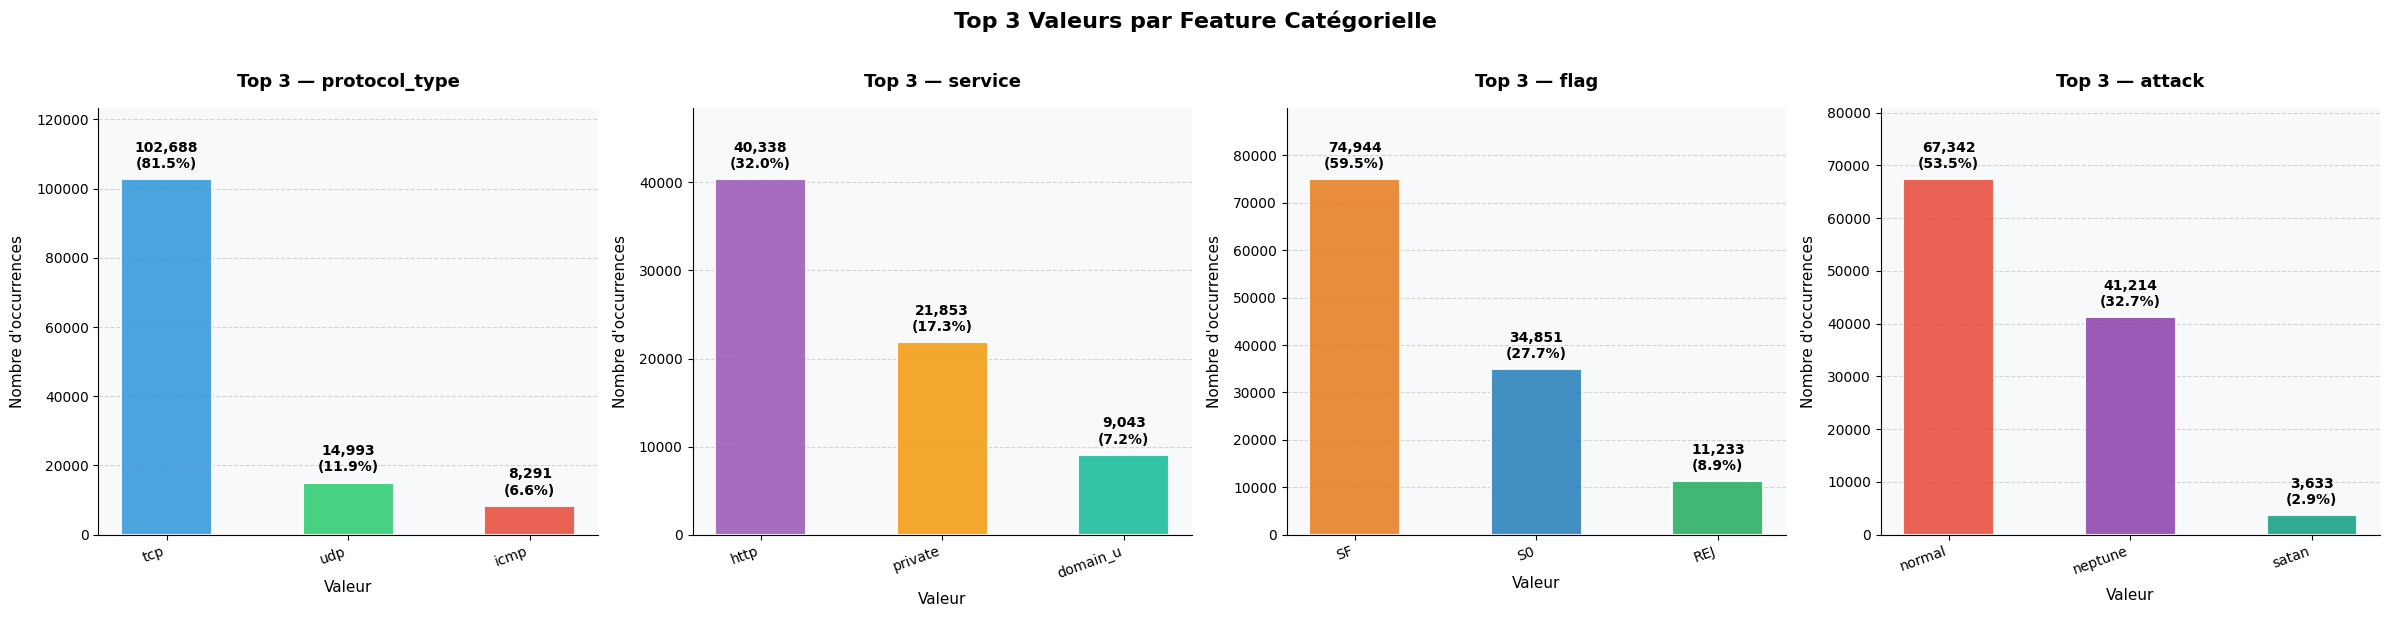

In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_top3_categorical(df, columns):
    """
    Affiche un histogramme des 3 premières valeurs 
    pour chaque colonne catégorielle.
    """
    n_cols = len(columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))
    
    # Si une seule colonne, axes n'est pas une liste
    if n_cols == 1:
        axes = [axes]
    
    color_palette = [
        ['#3498db', '#2ecc71', '#e74c3c'],  # protocol_type
        ['#9b59b6', '#f39c12', '#1abc9c'],  # service
        ['#e67e22', '#2980b9', '#27ae60'],  # flag
        ['#e74c3c', '#8e44ad', '#16a085'],  # attack
    ]
    
    for idx, (column_name, ax) in enumerate(zip(columns, axes)):
        
        # Top 3 valeurs
        top3 = df[column_name].value_counts().head(3)
        labels = top3.index.tolist()
        valeurs = top3.values.tolist()
        colors = color_palette[idx % len(color_palette)]
        
        # Barplot
        bars = ax.bar(
            labels,
            valeurs,
            width=0.5,
            color=colors,
            edgecolor='white',
            linewidth=1.5,
            alpha=0.88,
            zorder=2
        )
        
        # Titre et labels
        ax.set_title(f'Top 3 — {column_name}',
                     fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel('Valeur', fontsize=11, labelpad=8)
        ax.set_ylabel('Nombre d\'occurrences', fontsize=11, labelpad=8)
        
        # Rotation labels si trop longs
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
        
        # Grille
        ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_facecolor('#f8f9fa')
        
        # Valeurs + pourcentage sur les barres
        total = df[column_name].count()
        for bar, val in zip(bars, valeurs):
            pct = (val / total) * 100
            ax.annotate(
                f'{val:,}\n({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 6),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color='black'
            )
        
        # Marge Y pour les annotations
        ax.set_ylim(0, max(valeurs) * 1.2)
    
    # Titre global
    fig.suptitle('Top 3 Valeurs par Feature Catégorielle',
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig('top3_categorical.png', dpi=300, bbox_inches='tight')
    plt.show()


# --- Appel de la fonction ---
categorical_columns = ['protocol_type', 'service', 'flag', 'attack']
plot_top3_categorical(df, cat_features)

In [13]:
tab=df["attack"].unique()
[x.lower() for x in tab]

['normal',
 'neptune',
 'warezclient',
 'ipsweep',
 'portsweep',
 'teardrop',
 'nmap',
 'satan',
 'smurf',
 'pod',
 'back',
 'guess_passwd',
 'ftp_write',
 'multihop',
 'rootkit',
 'buffer_overflow',
 'imap',
 'warezmaster',
 'phf',
 'land',
 'loadmodule',
 'spy',
 'perl']

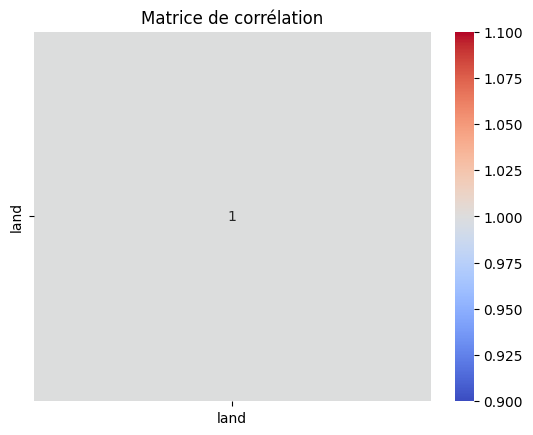

In [88]:
features_trafic = [
    'flag', 
    'land'
    
]
import numpy as np 
corr = df[features_trafic].corr(numeric_only=True) 
sns.heatmap(corr, annot=True, 
cmap="coolwarm") 
plt.title("Matrice de corrélation") 
plt.show()

In [48]:
#le nombre de connexions par catégorie d'attaque
# Définir les 5 grandes catégories
mapping = {
    'normal'           : 'Normal',
    'neptune'          : 'DoS',
    'smurf'            : 'DoS',
    'pod'              : 'DoS',
    'teardrop'         : 'DoS',
    'land'             : 'DoS',
    'back'             : 'DoS',
    'portsweep'        : 'Probe',
    'ipsweep'          : 'Probe',
    'nmap'             : 'Probe',
    'satan'            : 'Probe',
    'warezclient'      : 'R2L',
    'warezmaster'      : 'R2L',
    'guess_passwd'     : 'R2L',
    'ftp_write'        : 'R2L',
    'imap'             : 'R2L',
    'phf'              : 'R2L',
    'multihop'         : 'R2L',
    'spy'              : 'R2L',
    'buffer_overflow'  : 'U2R',
    'rootkit'          : 'U2R',
    'loadmodule'       : 'U2R',
    'perl'             : 'U2R',
}

# Créer une nouvelle colonne avec les grandes catégories
df['attack_category'] = df['attack'].map(mapping)
#print(df['attack_category'])
print(df.shape)
# Compter par grande catégorie
#df['attack_category'].value_counts()

(125972, 44)


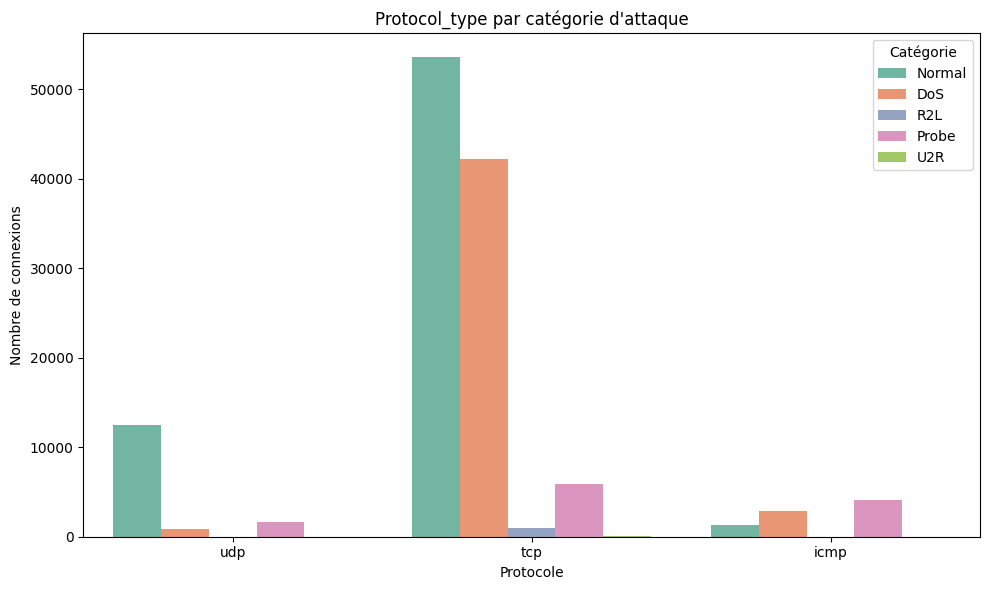

In [53]:
plt.figure(figsize=(10, 6))
sns.countplot(
    x='protocol_type', 
    hue='attack_category',
    data=df,
    palette='Set2'
)
plt.title('Protocol_type par catégorie d\'attaque')
plt.xlabel('Protocole')
plt.ylabel('Nombre de connexions')
plt.legend(title='Catégorie')
plt.tight_layout()
plt.show()

  Catégorie  Moyenne Duration
0       DoS          0.006227
1    Normal        168.589899
2     Probe       2074.858185
3       R2L        633.417085
4       U2R         80.942308


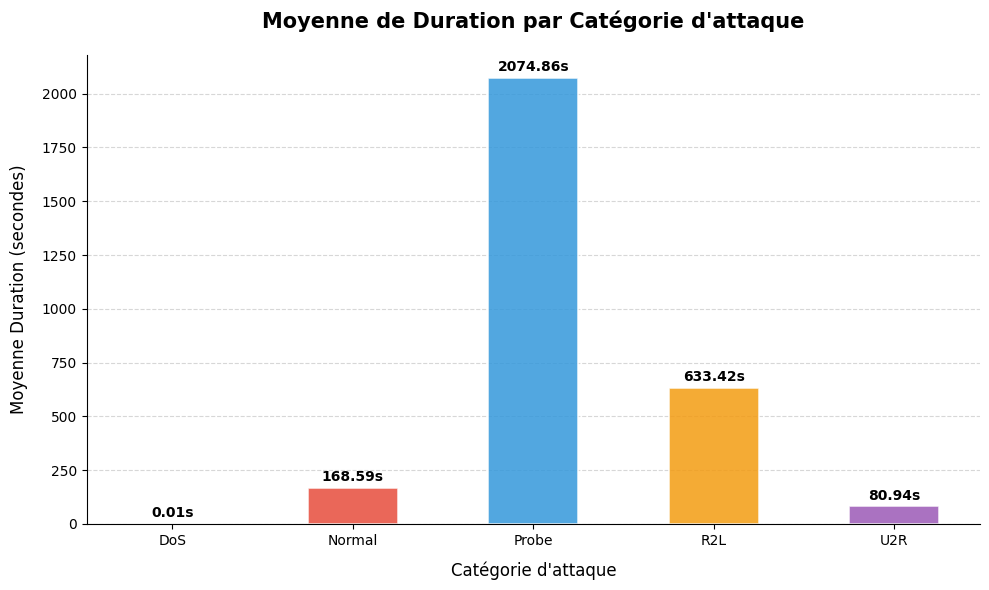

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Calculer la moyenne de duration par catégorie
mean_duration = df.groupby('attack_category')['duration'].mean().reset_index()
mean_duration.columns = ['Catégorie', 'Moyenne Duration']

print(mean_duration)
categories = mean_duration['Catégorie']
valeurs = mean_duration['Moyenne Duration']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    categories,
    valeurs,
    width=0.5,
    color=colors,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85,
    zorder=2
)

# Titre et labels
ax.set_title('Moyenne de Duration par Catégorie d\'attaque',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Catégorie d\'attaque', fontsize=12, labelpad=10)
ax.set_ylabel('Moyenne Duration (secondes)', fontsize=12, labelpad=10)

# Grille
ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Valeurs sur les barres
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}s',
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold',
                color='black')

plt.tight_layout()
plt.savefig('mean_duration_par_attaque.png', dpi=300, bbox_inches='tight')
plt.show()

#### Ce résultat montre clairement le déséquilibre de classes — U2R est extrêmement rare avec seulement 52 connexions, ce qui est une observation importante pour votre rapport car cela rend sa détection très difficile pour le modèle ML.

In [129]:
counts = df_test['attack_category'].value_counts()
print(counts)
pourcentage = df_test['attack_category'].value_counts(normalize=True) * 100
#normalize=True Retourne la proportion de chaque catégorie par rapport au total — des valeurs entre 0 et 1
print(pourcentage.round(2))

attack_category
0    4344
3    2884
2    2402
1    2152
4      67
Name: count, dtype: int64
attack_category
0    36.66
3    24.34
2    20.27
1    18.16
4     0.57
Name: proportion, dtype: float64


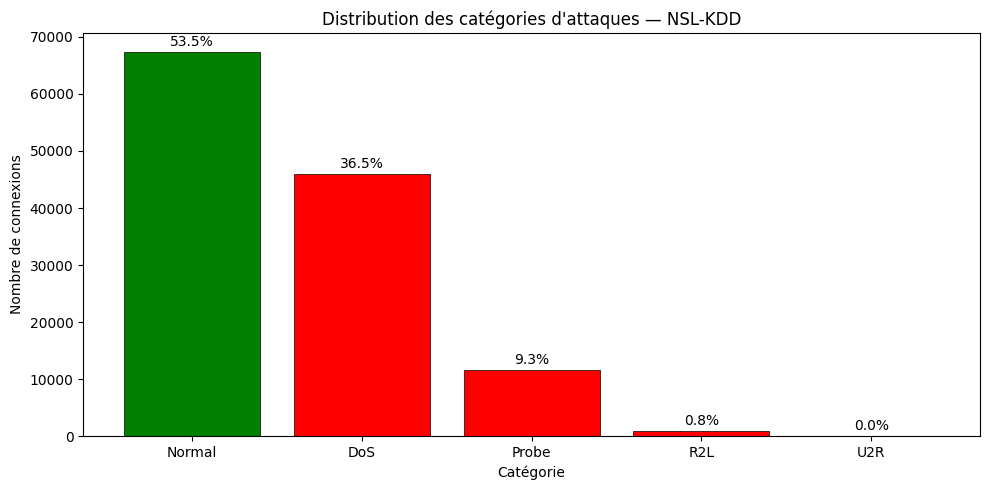

In [20]:
colors = ['green' if x == 'Normal' else 'red' for x in counts.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, pct in zip(bars, pourcentage[counts.index]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'{pct:.1f}%',
             ha='center', va='bottom', fontsize=10)

plt.title("Distribution des catégories d'attaques — NSL-KDD")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de connexions")
plt.tight_layout()
plt.show()

In [21]:
# Voir les valeurs de attack qui n'ont pas été mappées
print(df[df['attack_category'].isna()]['attack'].value_counts())

Series([], Name: count, dtype: int64)


In [24]:
# Vérifier que le total est correct
print(67342 + 45927 + 11656 + 995 + 52)
# → 125972  — correspond exactement à df.shape[0]

125972


In [83]:
df_test.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level,attack_category
0,0,2,44,9,44,0,0,0,0,0,...,0.01,0.01,0.0,0.00,0.00,0.00,0.0,29,12,5
1,0,1,53,8,0,44,0,0,0,0,...,0.61,0.00,0.0,0.21,0.68,0.60,0.0,21,18,5
2,0,2,44,9,53,55,0,0,0,0,...,0.00,0.87,0.0,0.00,0.00,0.00,0.0,16,17,1
3,0,1,44,10,0,0,0,0,0,0,...,1.00,1.00,0.0,1.00,1.00,0.00,0.0,15,17,2
4,0,1,22,9,54540,8314,0,0,0,2,...,0.01,0.00,0.0,0.00,0.00,0.01,0.0,1,10,0


#### encoding

In [110]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ── 1. Charger les fichiers ───────────────────────────────────────────────────
#df_test  = pd.read_csv(r'C:\Users\21276\Desktop\master Fp\python avancee\mini-project\KDDTest+.csv')
mapping  = pd.read_csv(r'C:\Users\21276\Desktop\master Fp\python avancee\mini-project\encoding_mapping.csv')

print("df_test  :", df_test.shape)
print("mapping  :", mapping.shape)

# ── 2. Reconstruire les label_encoders depuis le mapping ─────────────────────
label_encoders = {}

for col in mapping['column'].unique():
    col_mapping = (mapping[mapping['column'] == col]
                   .sort_values('encoded_value'))
    
    le = LabelEncoder()
    le.classes_ = col_mapping['original_value'].values  # reconstruire les classes
    label_encoders[col] = le

print("\n✅ Encodeurs reconstruits pour :", list(label_encoders.keys()))

df_test  : (11849, 43)
mapping  : (112, 3)

✅ Encodeurs reconstruits pour : ['protocol_type', 'service', 'flag', 'attack', 'attack_category']


In [112]:
# ── 3. Ajouter attack_category sur df_test ───────────────────────────────────
# httptunnel = tunnel HTTP pour contourner les firewalls → R2L
attack_map = {
    'normal'          : 'Normal',
    # DoS
    'neptune'         : 'DoS', 'back'           : 'DoS', 'land'          : 'DoS',
    'pod'             : 'DoS', 'smurf'          : 'DoS', 'teardrop'      : 'DoS',
    'processtable'    : 'DoS', 'udpstorm'       : 'DoS', 'mailbomb'      : 'DoS',
    'apache2'         : 'DoS', 'worm'           : 'DoS',
    # Probe
    'ipsweep'         : 'Probe', 'nmap'         : 'Probe', 'portsweep'   : 'Probe',
    'satan'           : 'Probe', 'saint'        : 'Probe', 'mscan'       : 'Probe',
    # R2L
    'ftp_write'       : 'R2L', 'guess_passwd'   : 'R2L', 'imap'         : 'R2L',
    'multihop'        : 'R2L', 'phf'            : 'R2L', 'spy'          : 'R2L',
    'warezclient'     : 'R2L', 'warezmaster'    : 'R2L', 'snmpguess'    : 'R2L',
    'snmpgetattack'   : 'R2L', 'named'          : 'R2L', 'xlock'        : 'R2L',
    'xsnoop'          : 'R2L', 'sendmail'       : 'R2L', 'httptunnel'   : 'R2L', # ← ajouté
    # U2R
    'buffer_overflow' : 'U2R', 'loadmodule'     : 'U2R', 'perl'         : 'U2R',
    'rootkit'         : 'U2R', 'sqlattack'      : 'U2R', 'xterm'        : 'U2R',
    'ps'              : 'U2R',
}

df_test['attack_category'] = df_test['attack'].map(attack_map)

# Vérifier les vides
inconnus = df_test[df_test['attack_category'].isna()]['attack'].unique()
if len(inconnus) > 0:
    print(f"⚠️ Attaques non mappées : {inconnus}")
    df_test['attack_category'] = df_test['attack_category'].fillna('Unknown')
else:
    print("✅ Toutes les attaques sont mappées")

✅ Toutes les attaques sont mappées


In [113]:
# ── 4. Encoder df_test ───────────────────────────────────────────────────────
cat_cols = df_test.select_dtypes(include='object').columns.tolist()
print("Colonnes à encoder :", cat_cols)

for col in cat_cols:
    if col not in label_encoders:
        print(f"⚠️ Pas d'encodeur pour {col} — ignoré")
        continue
    
    le = label_encoders[col]
    valeurs_connues = set(le.classes_)
    
    # Remplacer valeurs inconnues
    inconnus_col = df_test[col][~df_test[col].isin(valeurs_connues)].unique()
    if len(inconnus_col) > 0:
        print(f"⚠️ {col} — valeurs inconnues remplacées : {inconnus_col}")
        df_test[col] = df_test[col].apply(
            lambda x: x if x in valeurs_connues else le.classes_[0]
        )
    
    df_test[col] = le.transform(df_test[col])

# ── 5. Vérifier ──────────────────────────────────────────────────────────────
remaining = df_test.select_dtypes(include='object').columns.tolist()
if len(remaining) == 0:
    print("\n✅ df_test entièrement encodé")
else:
    print(f"❌ Colonnes encore en object : {remaining}")

# ── 6. Sauvegarder ───────────────────────────────────────────────────────────
df_test.to_csv(r'C:\Users\21276\Desktop\master Fp\python avancee\mini-project\nss_kdd_test_encoded.csv', index=False)
print("✅ nss_kdd_test_encoded.csv sauvegardé")
print(df_test.head(3))

Colonnes à encoder : ['protocol_type', 'service', 'flag', 'attack', 'attack_category']
⚠️ attack — valeurs inconnues remplacées : ['snmpguess' 'processtable' 'saint' 'mscan' 'apache2' 'httptunnel'
 'mailbomb' 'snmpgetattack' 'worm' 'sendmail' 'xlock' 'xterm' 'xsnoop'
 'ps' 'named' 'udpstorm' 'sqlattack']

✅ df_test entièrement encodé
✅ nss_kdd_test_encoded.csv sauvegardé
   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0         0              2       49     9         44          0     0   
1         0              1       60     8          0         44     0   
2         0              2       49     9         53         55     0   

   wrong_fragment  urgent  hot  ...  dst_host_diff_srv_rate  \
0               0       0    0  ...                    0.01   
1               0       0    0  ...                    0.61   
2               0       0    0  ...                    0.00   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0                

In [118]:
df_test['attack_category'].head(2)

0    3
1    0
Name: attack_category, dtype: int32

In [9]:
# ── Définir X et y ───────────────────────────────────────────────────────────

# y = la cible (ce qu'on veut prédire)
y = df['attack_category']   # Normal, DoS, Probe, R2L, U2R

# X = toutes les features SAUF les colonnes liées à la cible
X = df.drop(columns=[
    'attack',        # sous-types originaux (neptune, smurf...) → trop précis, c'est la source de attack_type
    'attack_category',   # la cible qu'on vient de définir
    'level'          # score de sévérité, dérivé de attack → fuite d'information
])

print("Shape de X :", X.shape)   # (125972, 40)
print("Shape de y :", y.shape)   # (125972,)
print("\nColonnes de X :\n", X.columns.tolist())

Shape de X : (125972, 41)
Shape de y : (125972,)

Colonnes de X :
 ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [70]:
# ── Charger les deux fichiers encodés ────────────────────────────────────────
df_train = pd.read_csv(r'C:\Users\21276\Desktop\master Fp\python avancee\mini-project\nss_kdd_encoded.csv')
df_test  = pd.read_csv(r'C:\Users\21276\Desktop\master Fp\python avancee\mini-project\nss_kdd_test_encoded.csv')

# ── Définir X et y pour train ─────────────────────────────────────────────────
cols_to_drop = ['attack', 'attack_category', 'level']

X_train = df_train.drop(columns=cols_to_drop)
y_train = df_train['attack_category']

# ── Définir X et y pour test ──────────────────────────────────────────────────
X_test  = df_test.drop(columns=cols_to_drop)
y_test  = df_test['attack_category']

# ── Vérifier ─────────────────────────────────────────────────────────────────
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

print("\nDistribution y_train :\n", y_train.value_counts())
print("\nDistribution y_test  :\n", y_test.value_counts())

X_train : (125972, 41)
y_train : (125972,)
X_test  : (11849, 41)
y_test  : (11849,)

Distribution y_train :
 attack_category
1    67342
0    45927
2    11656
3      995
4       52
Name: count, dtype: int64

Distribution y_test  :
 attack_category
0    4344
3    2884
2    2402
1    2152
4      67
Name: count, dtype: int64


In [16]:
print("Colonnes dans X :")
print(X.columns.tolist())

Colonnes dans X :
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [15]:
df1.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level,attack_category
0,0,2,44,9,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.0,0.00,11,15,1
1,0,1,49,5,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.0,0.00,9,19,0
2,0,1,24,9,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.0,0.01,11,21,1
3,0,1,24,9,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,11,21,1
4,0,1,49,1,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.0,1.00,9,21,0


In [22]:
y_test.head(5)

35557    0
69687    0
58469    1
32098    0
54458    0
Name: attack_category, dtype: int64

### RandomForest

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

model = RandomForestClassifier(
    n_estimators=700,
    max_depth=20,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',
    max_samples=0.8,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

In [24]:
scaler = StandardScaler()
X_res_scaled  = scaler.fit_transform(X_res)    # fit + transform sur train
X_test_scaled = scaler.transform(X_test)       # transform seulement sur test

In [26]:
randomForest=model.fit(X_res_scaled, y_res)

In [27]:
y_pred = randomForest.predict(X_test)

C:\Users\21276\anaconda3\envs\tf310_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [28]:
# ✅ Ordre correct selon encoded_value
attack_labels = ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

print(classification_report(y_test, y_pred, target_names=attack_labels))

              precision    recall  f1-score   support

         DoS       0.00      0.00      0.00      4344
      Normal       0.18      1.00      0.31      2152
       Probe       0.00      0.00      0.00      2402
         R2L       0.00      0.00      0.00      2884
         U2R       0.00      0.00      0.00        67

    accuracy                           0.18     11849
   macro avg       0.04      0.20      0.06     11849
weighted avg       0.03      0.18      0.06     11849



C:\Users\21276\anaconda3\envs\tf310_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\21276\anaconda3\envs\tf310_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\21276\anaconda3\envs\tf310_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [29]:
accuracy = randomForest.score(X_test, y_test)
print(f"Accuracy : {accuracy:.4f}")        # ex: 0.9987
print(f"Accuracy : {accuracy*100:.2f}%")   # ex: 99.87%

C:\Users\21276\anaconda3\envs\tf310_env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Accuracy : 0.1816
Accuracy : 18.16%


### smote

In [71]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
# ── Stratégie combinée : undersampling Normal + oversampling R2L/U2R ──────────
undersample = RandomUnderSampler(
    sampling_strategy={
        1 : 20000,   # Normal  : 67342 → 20000  ← réduire
        0 : 20000,   # DoS     : 45927 → 20000  ← réduire
    },
    random_state=42
)

oversample = SMOTE(
    sampling_strategy={
        3 : 15000,   # R2L  : 993   → 15000
        4 : 10000,   # U2R  : 52    → 10000
        2 : 15000,   # Probe : 11656 → 15000
    },
    k_neighbors=3,
    random_state=42
)

# Appliquer dans l'ordre
X_res, y_res = undersample.fit_resample(X_train, y_train)
X_res, y_res = oversample.fit_resample(X_res, y_res)

print("Distribution finale :")
print(pd.Series(y_res).value_counts().sort_index())
# DoS    → 20000
# Normal → 20000
# Probe  → 15000
# R2L    → 15000
# U2R    → 10000

Distribution finale :
attack_category
0    20000
1    20000
2    15000
3    15000
4    10000
Name: count, dtype: int64


### XGboost

In [77]:
# ── Entraîner avec poids supplémentaires ─────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

poids = {0: 1, 1: 1, 2: 2, 3: 5, 4: 10}
sample_weights = compute_sample_weight(class_weight=poids, y=y_res)

model_xgb2 = XGBClassifier(
    n_estimators=500,
    max_depth=50,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

model_xgb2.fit(X_res, y_res, sample_weight=sample_weights)

# ── Évaluer ───────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, accuracy_score

attack_labels = ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
y_pred2 = model_xgb2.predict(X_test)

print(f"\nAccuracy : {accuracy_score(y_test, y_pred2)*100:.2f}%")
print(classification_report(y_test, y_pred2, target_names=attack_labels))


Accuracy : 61.84%
              precision    recall  f1-score   support

         DoS       0.93      0.73      0.82      4344
      Normal       0.33      0.87      0.48      2152
       Probe       0.80      0.75      0.77      2402
         R2L       0.98      0.17      0.28      2884
         U2R       0.58      0.31      0.41        67

    accuracy                           0.62     11849
   macro avg       0.73      0.56      0.55     11849
weighted avg       0.81      0.62      0.61     11849



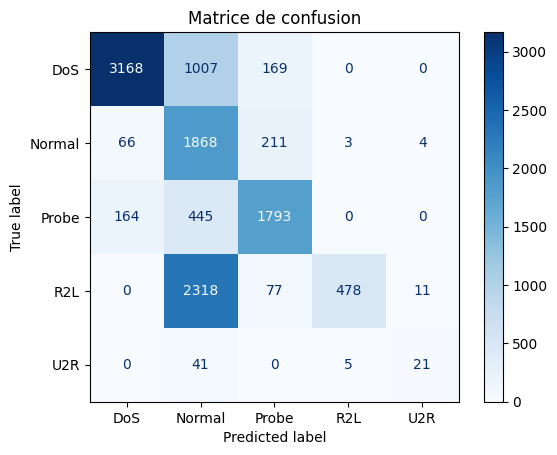

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')

plt.title("Matrice de confusion")
plt.show()

In [80]:
import pickle

# Sauvegarder après le fit
#with open(r'C:\Users\21276\Desktop\master Fp\python avancee\mini-project\model_xgb2.pkl', 'wb') as f:
    #pickle.dump(model_xgb2, f)

#print("✅ Modèle sauvegardé : model_xgb2.pkl")

# Charger plus tard
with open(r'C:\Users\21276\Desktop\master Fp\python avancee\mini-project\model_xgb2.pkl', 'rb') as f:
    model_charge = pickle.load(f)

print("✅ Modèle chargé avec succès")

✅ Modèle chargé avec succès


In [74]:
# ── Diagnostic : matrice de confusion ────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

attack_labels = ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

cm   = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matrice de Confusion — XGBoost')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Voir exactement où le modèle se trompe ────────────────────────────────────
cm_df = pd.DataFrame(cm, index=attack_labels, columns=attack_labels)
print("\nMatrice de confusion :")
print(cm_df)

# ── Comparer distribution train vs test ───────────────────────────────────────
print("\nDistribution y_train :")
train_dist = pd.Series(y_train_bal).value_counts().sort_index()
for code, count in train_dist.items():
    print(f"  {attack_labels[code]:10s} → {count}")

print("\nDistribution y_test :")
test_dist = pd.Series(y_test).value_counts().sort_index()
for code, count in test_dist.items():
    print(f"  {attack_labels[code]:10s} → {count}")

NameError: name 'y_pred_xgb' is not defined

In [55]:
X.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,2,44,9,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00
1,0,1,49,5,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00
2,0,1,24,9,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01
3,0,1,24,9,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
4,0,1,49,1,0,0,0,0,0,0,...,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00


In [39]:
from sklearn.metrics import classification_report

#### decision tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
   criterion='gini',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=None,
    max_leaf_nodes=None,
    class_weight='balanced',
    ccp_alpha=0.001,
    random_state=42
)
DecisionTree=model_dt.fit(X_res, y_res)
y_pred_dt = model_dt.predict(X_test)

In [47]:
print(classification_report(y_test, y_pred_dt, 
      target_names=['DoS', 'Normal', 'Probe', 'R2L', 'U2R']))

              precision    recall  f1-score   support

         DoS       0.92      0.69      0.79      4344
      Normal       0.39      0.81      0.53      2152
       Probe       0.55      0.83      0.66      2402
         R2L       0.26      0.02      0.04      2884
         U2R       0.09      0.36      0.14        67

    accuracy                           0.58     11849
   macro avg       0.44      0.54      0.43     11849
weighted avg       0.58      0.58      0.53     11849



In [48]:
accuracy=DecisionTree.score(X_test, y_test)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 57.52%


Ordre des classes : ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


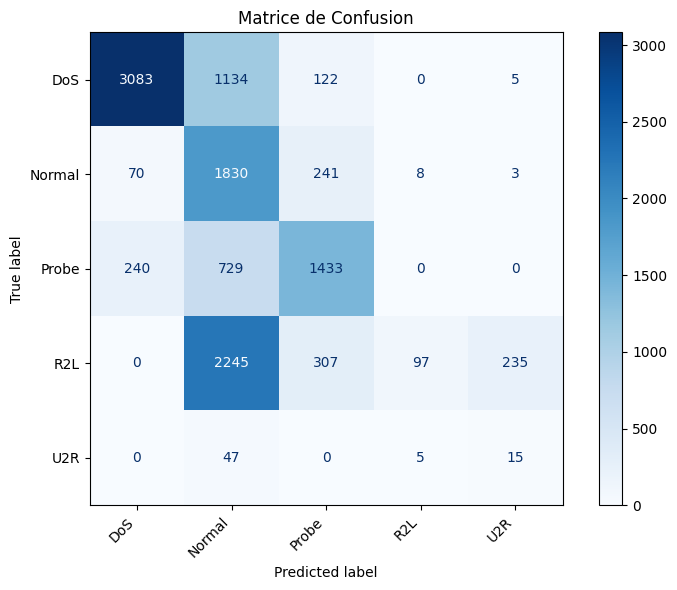

In [138]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ── 2. Labels depuis le mapping ──────────────────────────────────────────────
attack_labels = (mapping[mapping['column'] == 'attack_category']
                 .sort_values('encoded_value')['original_value']
                 .tolist())

print("Ordre des classes :", attack_labels)
# ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

# ── 3. Matrice + affichage ───────────────────────────────────────────────────
cm   = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=True)

plt.title('Matrice de Confusion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### logistic 

In [74]:
from sklearn.linear_model import LogisticRegression

Logistic_model = LogisticRegression(random_state=42)


In [75]:
Logistic = Logistic_model.fit(X_res,y_res)

C:\Users\21276\anaconda3\envs\tf310_env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
print(Logistic.score(X_test, y_test))

0.274200354460292


### SVM

In [5]:

from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
#from imblearn.over_sampling import SMOTE
#from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#X_res_scaled   = scaler.fit_transform(X_res)
#X_test_scaled  = scaler.transform(X_test)

In [ ]:
print("\n⏳ Entraînement SVM en cours (peut prendre quelques minutes)...")
model=model_svm.fit(X_res, y_res)


⏳ Entraînement SVM en cours (peut prendre quelques minutes)...
[LibSVM]

In [ ]:
print(model.score(model.score(X_test, y_test)))

In [15]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.0 MB/s eta 0:00:00


In [17]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    num_leaves=63,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model=model_lgbm.fit(X_res, y_res)
y_pred_lgbm = model_lgbm.predict(X_test)

print(f"Accuracy : {model.score(X_test, y_test)*100:.2f}%")
#print(classification_report(y_test, y_pred_lgbm, target_names=attack_labels))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007930 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5522
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 37
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

#### deuxieme entrainement - encoding

In [88]:
from sklearn.model_selection import train_test_split

X=df1.drop(columns=[
    'attack',        # sous-types originaux (neptune, smurf...) → trop précis, c'est la source de attack_type
    'attack_category',   # la cible qu'on vient de définir
    'level'          # score de sévérité, dérivé de attack → fuite d'information
])
y = df1["attack_category"]
print(X)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.1,random_state=43)

        duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0              0              2       44     9        146          0     0   
1              0              1       49     5          0          0     0   
2              0              1       24     9        232       8153     0   
3              0              1       24     9        199        420     0   
4              0              1       49     1          0          0     0   
...          ...            ...      ...   ...        ...        ...   ...   
125967         0              1       49     5          0          0     0   
125968         8              2       49     9        105        145     0   
125969         0              1       54     9       2231        384     0   
125970         0              1       30     5          0          0     0   
125971         0              1       20     9        151          0     0   

        wrong_fragment  urgent  hot  ...  dst_host_count  dst_h

In [89]:
train_index = X_train.columns
train_index

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate'],
      dtype='object')

In [90]:
from sklearn.feature_selection import mutual_info_classif #Est-ce que connaître la valeur de cette feature m'aide à deviner la classe ?
mutual_info = mutual_info_classif(X_train, y_train) 
mutual_info = pd.Series(mutual_info)
mutual_info.index = train_index
mutual_info.sort_values(ascending=False)
#Il mesure la dépendance entre chaque feature et la cible y

src_bytes                      0.714875
service                        0.595955
diff_srv_rate                  0.508199
flag                           0.497777
same_srv_rate                  0.471199
dst_bytes                      0.460234
dst_host_diff_srv_rate         0.450863
dst_host_srv_count             0.417965
count                          0.414589
dst_host_same_srv_rate         0.405376
dst_host_serror_rate           0.403804
serror_rate                    0.387923
dst_host_srv_serror_rate       0.376488
srv_serror_rate                0.362145
logged_in                      0.314297
dst_host_srv_diff_host_rate    0.261384
dst_host_same_src_port_rate    0.235670
dst_host_count                 0.213043
srv_count                      0.162393
srv_diff_host_rate             0.146637
dst_host_rerror_rate           0.097657
protocol_type                  0.089692
dst_host_srv_rerror_rate       0.084742
rerror_rate                    0.077530
duration                       0.058373


In [93]:
mutual_info.sort_values(ascending=False)

src_bytes                      0.714875
service                        0.595955
diff_srv_rate                  0.508199
flag                           0.497777
same_srv_rate                  0.471199
dst_bytes                      0.460234
dst_host_diff_srv_rate         0.450863
dst_host_srv_count             0.417965
count                          0.414589
dst_host_same_srv_rate         0.405376
dst_host_serror_rate           0.403804
serror_rate                    0.387923
dst_host_srv_serror_rate       0.376488
srv_serror_rate                0.362145
logged_in                      0.314297
dst_host_srv_diff_host_rate    0.261384
dst_host_same_src_port_rate    0.235670
dst_host_count                 0.213043
srv_count                      0.162393
srv_diff_host_rate             0.146637
dst_host_rerror_rate           0.097657
protocol_type                  0.089692
dst_host_srv_rerror_rate       0.084742
rerror_rate                    0.077530
duration                       0.058373


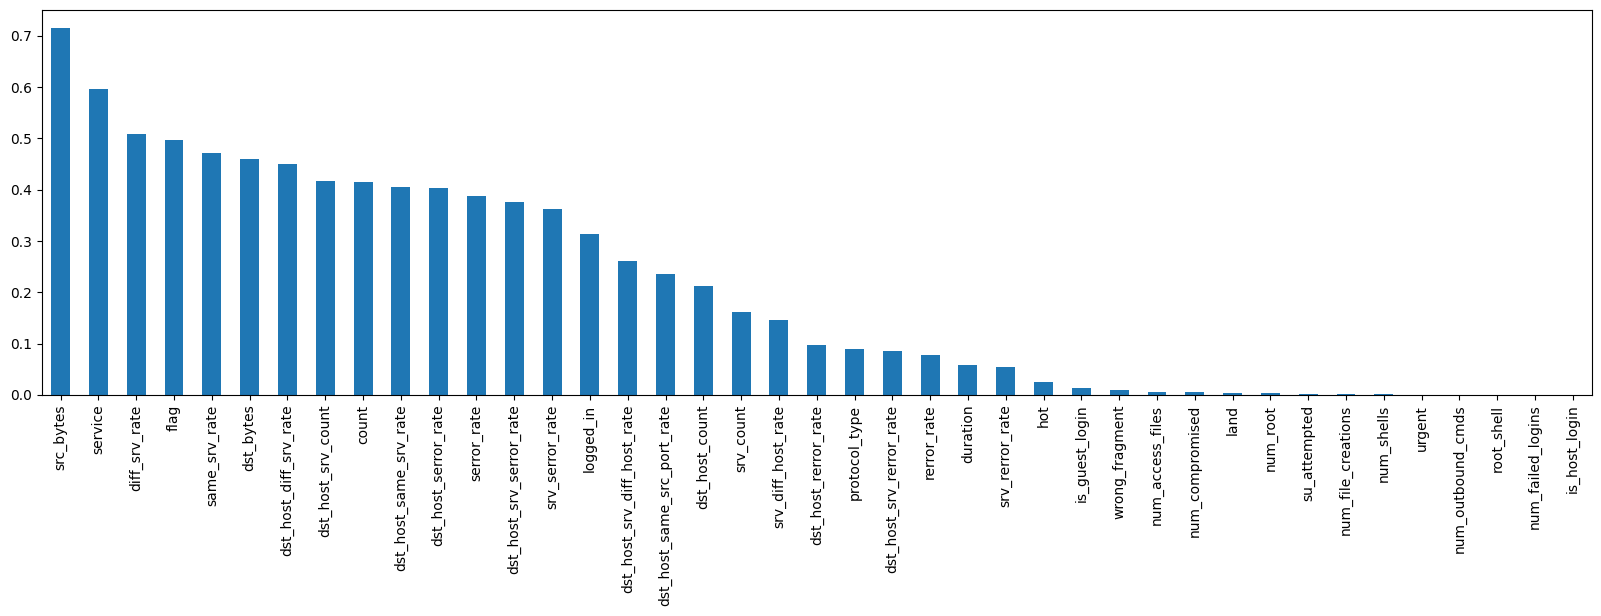

In [91]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 5));

In [92]:
from sklearn.feature_selection import SelectKBest
Select_features = SelectKBest(mutual_info_classif, k=30)
Select_features.fit(X_train, y_train)
train_index[Select_features.get_support()]

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'wrong_fragment', 'hot', 'logged_in', 'num_compromised',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate'],
      dtype='object')

In [30]:
columns = [
    "src_bytes",
    "service",
    "diff_srv_rate",
    "flag",
    "same_srv_rate",
    "dst_bytes",
    "dst_host_diff_srv_rate",
    "dst_host_srv_count",
    "count",
    "dst_host_same_srv_rate",
    "dst_host_serror_rate",
    "serror_rate",
    "dst_host_srv_serror_rate",
    "srv_serror_rate",
    "logged_in",
    "dst_host_srv_diff_host_rate",
    "dst_host_same_src_port_rate",
    "dst_host_count",
    "srv_count",
    "srv_diff_host_rate",
    "dst_host_rerror_rate",
    "protocol_type",
    "dst_host_srv_rerror_rate",
    "rerror_rate",
    "duration",
    "srv_rerror_rate",
    "hot",
    "is_guest_login"
]

#We will continue our model with top 15 features, because dataset is big enough

X_train=X_res[columns]
X_test=X_test[columns] 

In [174]:
X_train.head(3)

,src_bytes,service,diff_srv_rate,flag,same_srv_rate,dst_bytes,dst_host_diff_srv_rate,dst_host_srv_count,count,dst_host_same_srv_rate,...,srv_count,srv_diff_host_rate,dst_host_rerror_rate,protocol_type,dst_host_srv_rerror_rate,rerror_rate,duration,srv_rerror_rate,hot,is_guest_login
0,146,44,0.15,9,0.08,0,0.60,1,13,0.0,...,1,0.0,0.0,2,0.00,0.0,0,0.0,0,0
1,0,49,0.07,5,0.05,0,0.05,26,123,0.1,...,6,0.0,0.0,1,0.00,0.0,0,0.0,0,0
2,232,24,0.00,9,1.00,8153,0.00,255,5,1.0,...,5,0.0,0.0,1,0.01,0.0,0,0.0,0,0


In [79]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # we use only transform in order to prevent data leakage

In [80]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

In [89]:
import os

@st.cache_resource
def load_model():
    # Chemin absolu vers le modèle
    model_path = os.path.join(
        os.path.dirname(__file__), 
        'voting_classifier.pkl'  # nom exact de votre fichier
    )
    
    # Vérifier si le fichier existe
    if not os.path.exists(model_path):
        st.error(f"❌ Modèle introuvable : {model_path}")
        st.stop()
    
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    
    return model